In [1]:
%load_ext autoreload
%autoreload 2

# XTCAV Processing: Lasing Off Reference

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# XTCAV classes
from xtcav_processor import XTCAVProcessor
from xtcav_dark_reference import XTCAVDarkReference
from xtcav_lasing_off import XTCAVLasingOffReference

# Data access
import psana
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

# Setup

In [3]:
# ---------------
# Set run numbers 
# ---------------

runnum_dark = 152
runnum_lasingoff = 153
runnum_lasingon = 156

# Camera zoom-in field-of-view
fov = 180,320

# Dark Reference

Setting up data run times...
Done.


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting data source types...:   0%|          | 0/3279 [00:00<?, ?it/s]

Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


Calculating dark background reference:   0%|          | 0/100 [00:00<?, ?it/s]


Maximum number of images processed



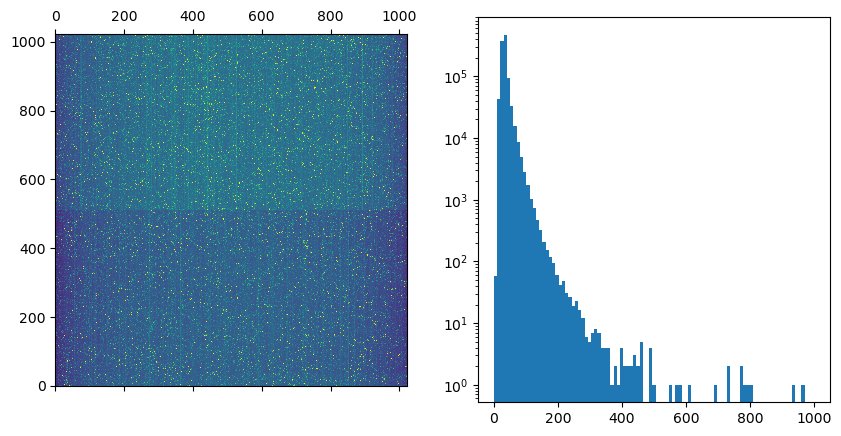

In [4]:
# Create object
xtdr = XTCAVDarkReference(
    get_datasource(runnum_dark),
    max_shots=100
)

# Show
xtdr.show(
    vrange = (0,1e2),
    bins = np.linspace(0,1000,100)
)

# Lasing-off reference

Setting up data run times...
Done.


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting data source types...:   0%|          | 0/5246 [00:00<?, ?it/s]

Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


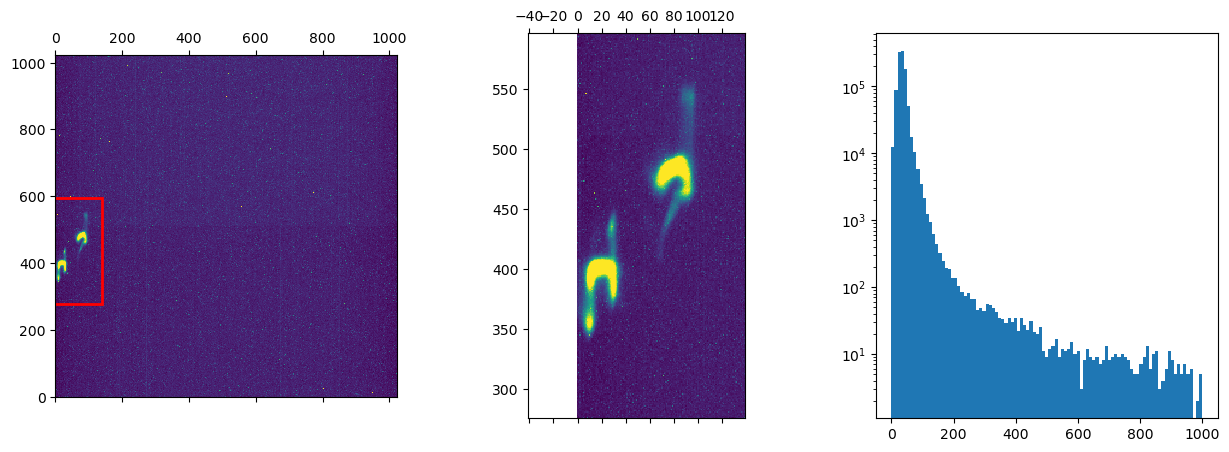

In [5]:
# Create object
xtpr = XTCAVLasingOffReference(
    get_datasource(runnum_lasingoff),
    shots_per_group=100
)

# Examine the first event
i,j,evt = next(xtpr.shot_iterator)
xtpr.set_current_event(evt)
xtpr.show_current_frame(
    vrange=(0,350),
    bins=np.linspace(0,1000,100),
    fov=fov
)

Looping through the next 3 'ok' events...
Showing 'ok' shot #2 at time index 155:


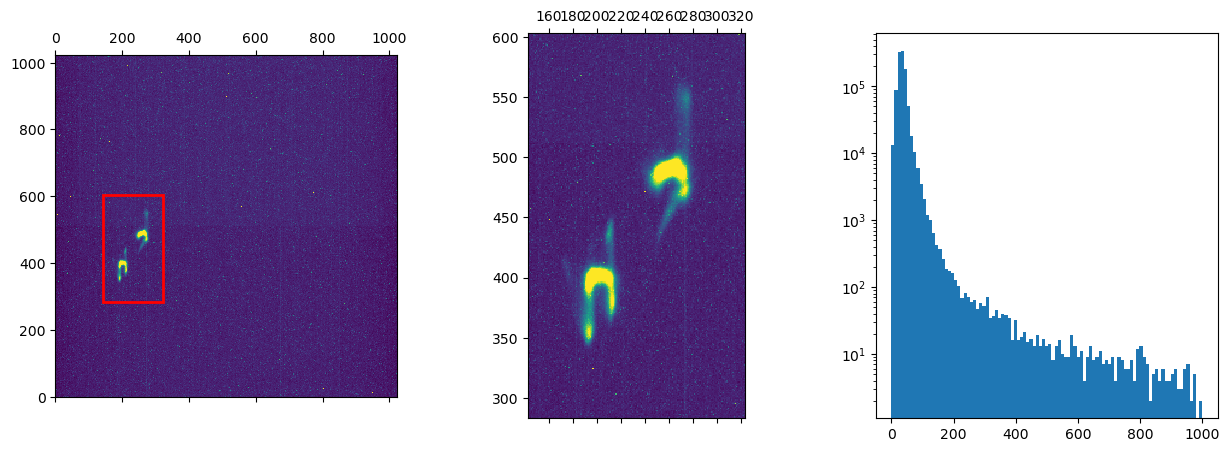

Showing 'ok' shot #3 at time index 156:


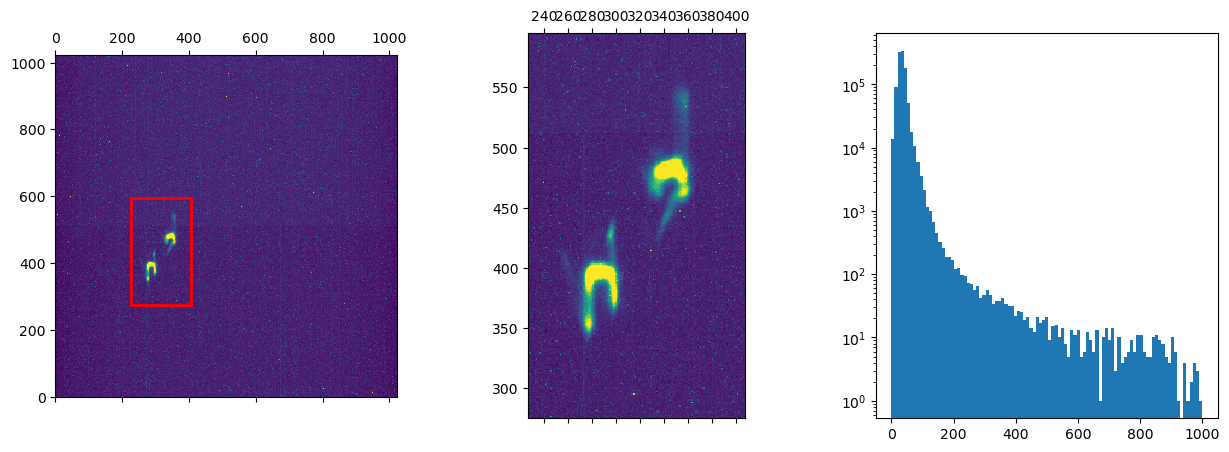

Showing 'ok' shot #4 at time index 157:


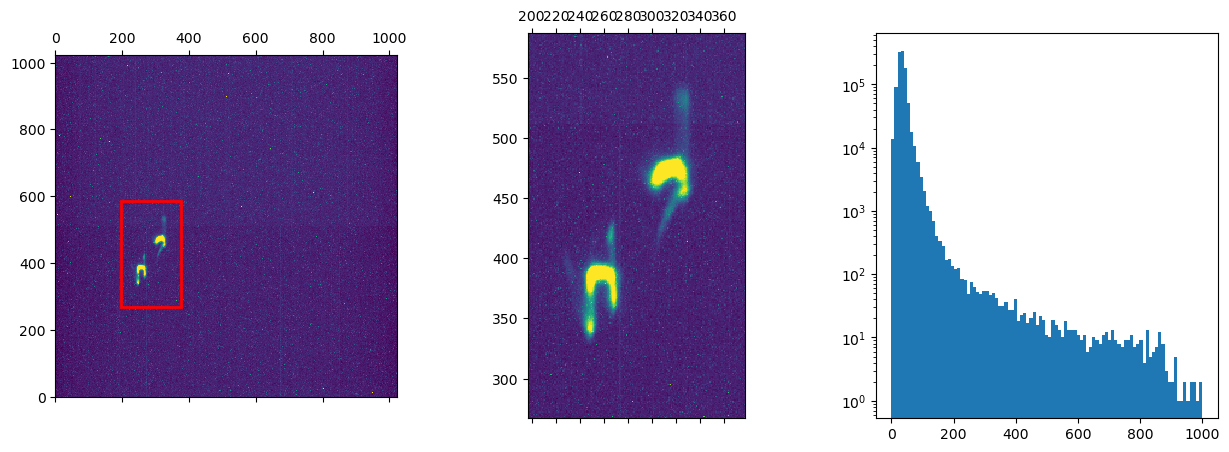

In [6]:
# Examine a few more events

n_shots_show = 3

print(f"Looping through the next {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame()

    # continue?
    if idx>=n_shots_show-1:
        break

Looping through the first 3 'ok' events...
Showing 'ok' shot #1 at time index 154:


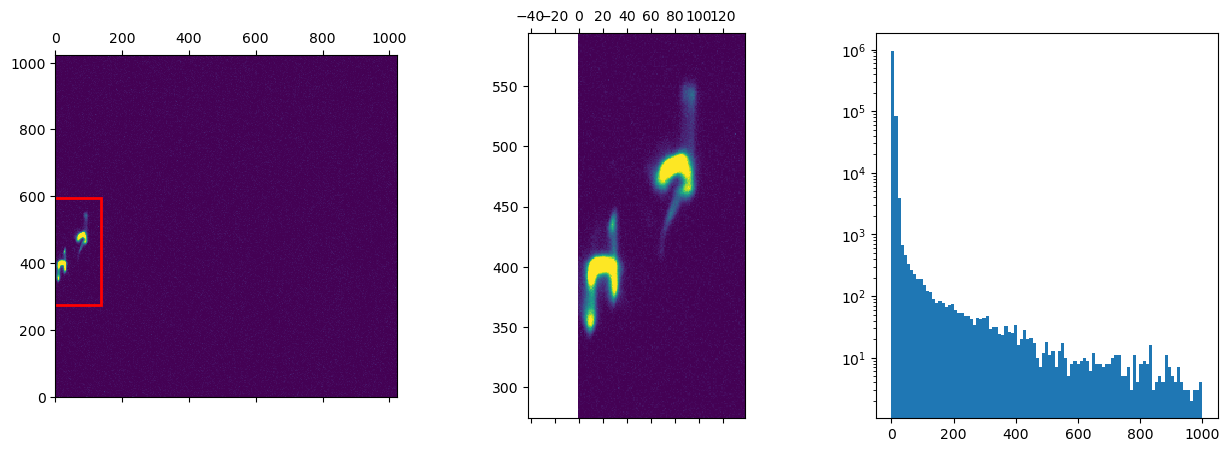

Showing 'ok' shot #2 at time index 155:


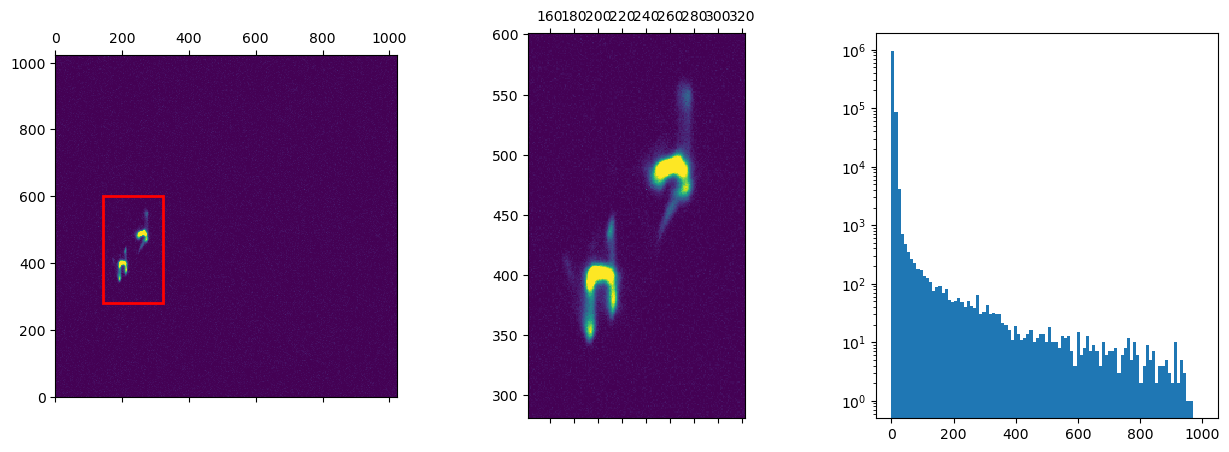

Showing 'ok' shot #3 at time index 156:


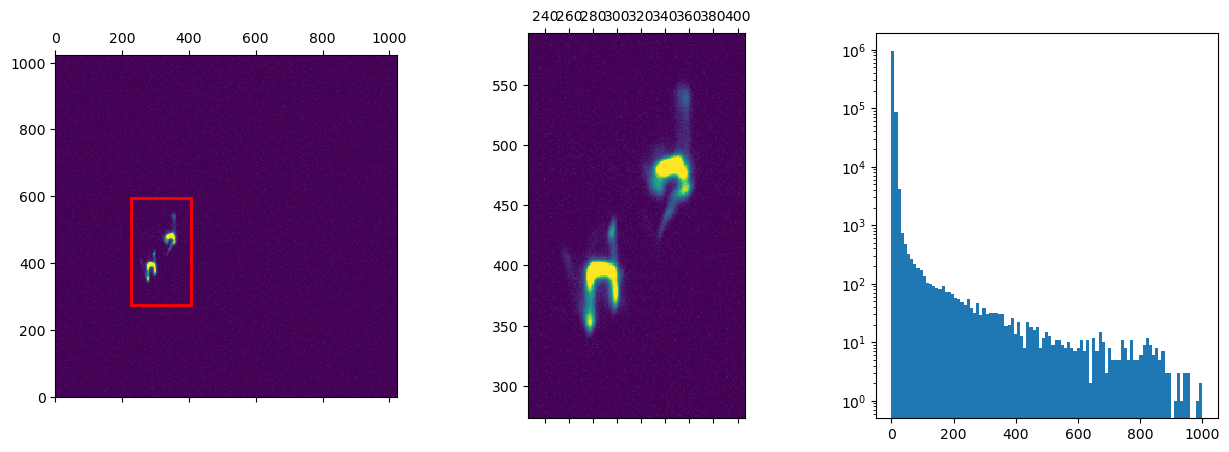

In [7]:
# Background subtraction

# Set dark ref
xtpr.set_darkreference(xtdr)

# Examine dark ref subtracted data
xtpr.reset_shot_iterator()
n_shots_show = 3
print(f"Looping through the first {n_shots_show} 'ok' events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing 'ok' shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

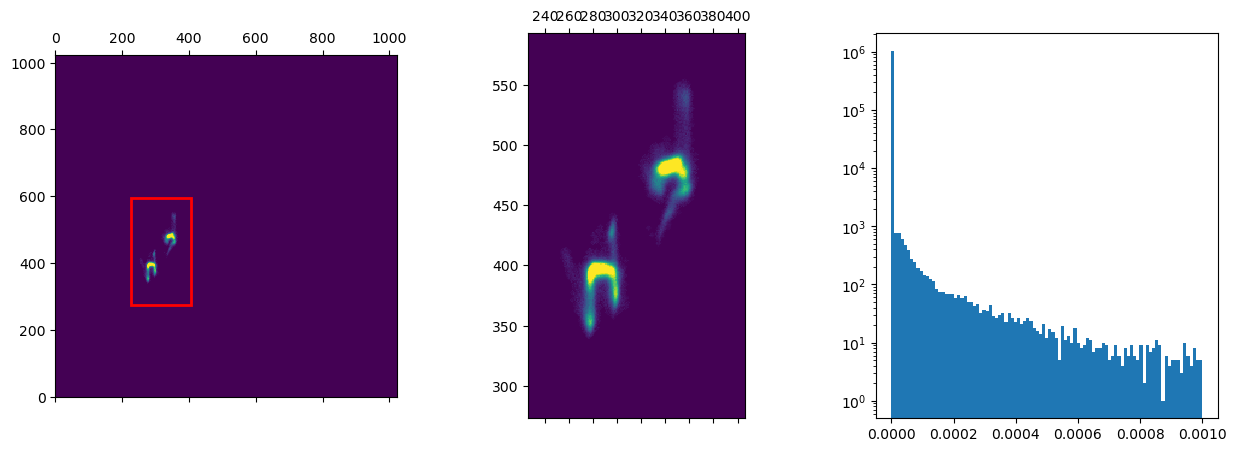

In [8]:
# Denoise

xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(
        nstd=1,                              # auto updates default params
        close=2
    ),
    vrange=(0,6e-4),                         # update intensity display range;
    bins=np.linspace(0,1e-3,100),            # denoising also normalizes total image intensity to 1
)

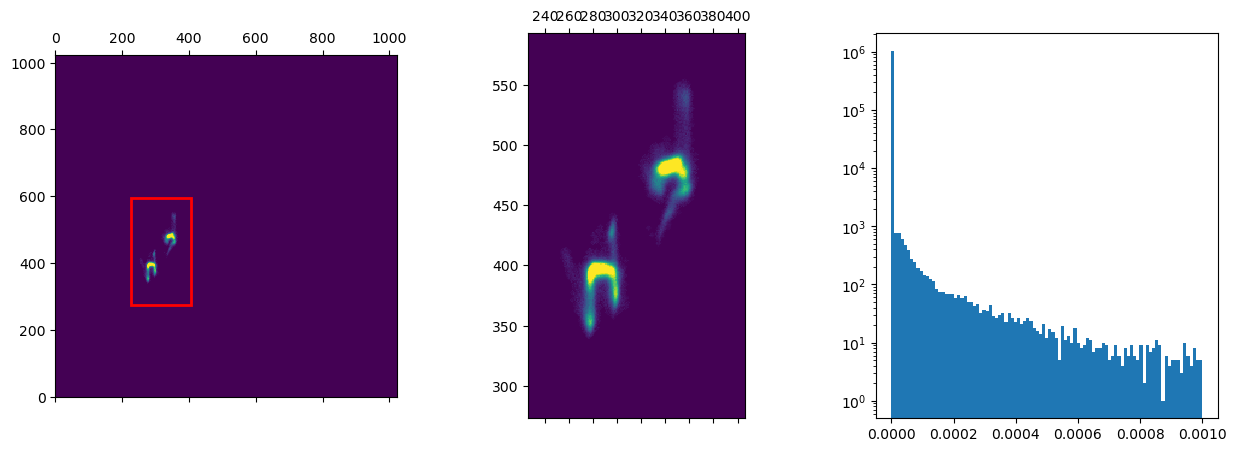

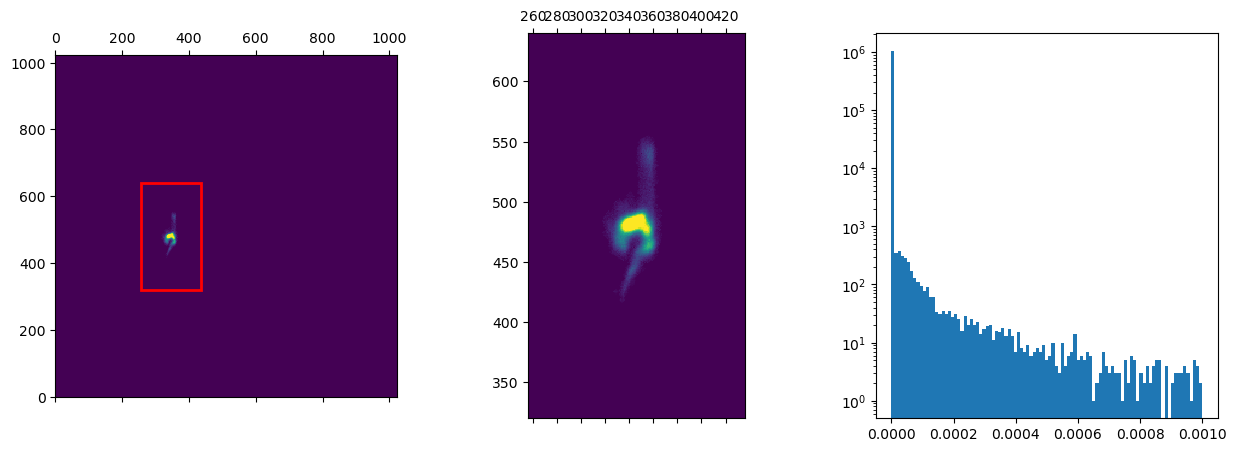

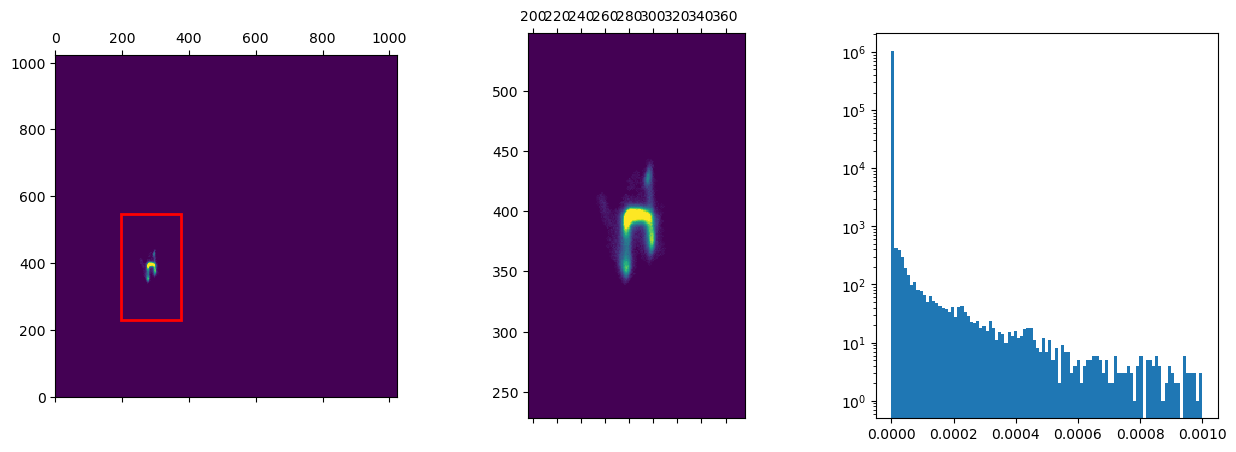

In [9]:
# Split images

# Get a denoised frame & split its pulses
im = xtpr.get_frame_denoised_current()
ims,ok = xtpr.split_frame(im,2)
assert(ok), "Failed to split image frame"

# Show
for image in (im,ims[0],ims[1]):   # Original image, pulse 1, and pulse 2
    xtpr.show_frame(image)

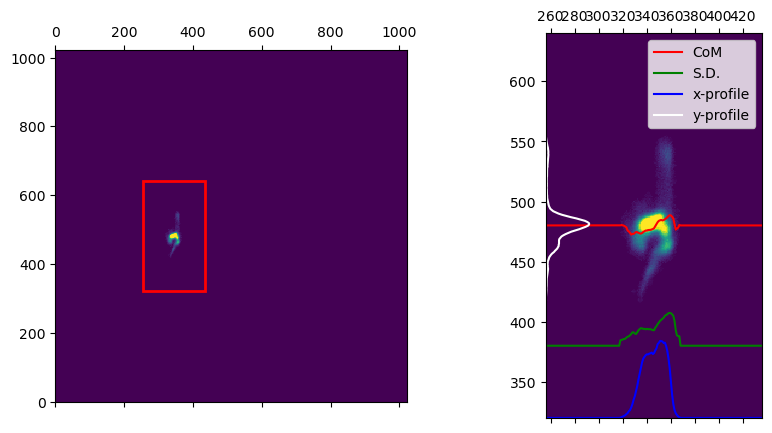

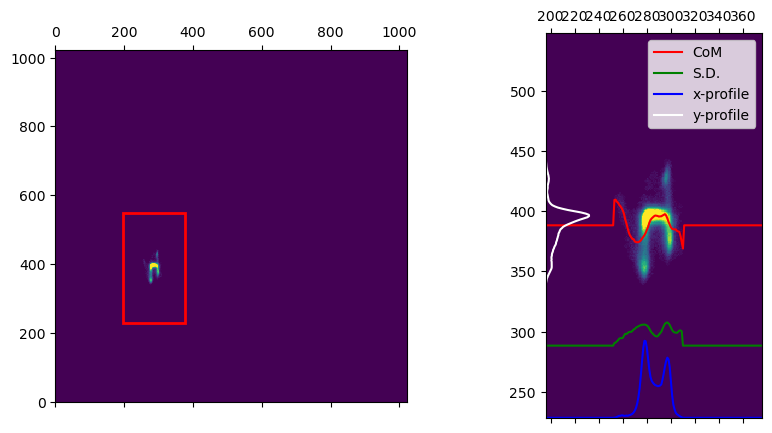

In [10]:
# Get image statistics

frame1,frame2 = ims[0],ims[1]
imageStats1 = xtpr.get_pulse_statistics(frame1)
imageStats2 = xtpr.get_pulse_statistics(frame2)

# Show
xtpr.show_frame_statistics(
    frame1,
    imageStats1,
)
xtpr.show_frame_statistics(
    frame2,
    imageStats2,
)

## Get full lasing-off data run image statistics

In [12]:
xtpr.get_shot_by_shot_statistics( n_pulses=2 )

Calculating shot-by-shot statistics...:   0%|          | 0/5246 [00:00<?, ?it/s]

/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1318: UserWarning: Hardcoded calibrations are not yet calculated - returning uncalibrated axes!
  warnings.warn("Hardcoded calibrations are not yet calculated - returning uncalibrated axes!")
/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:999: RuntimeWarning: invalid value encountered in divide
  ans /= np.sum(ans)


All 5246 shots have been traversed.
Resetting the shot iterator.
Done. Calculated statistics for 5035 shots.
Setting shot iterator to traverse good shots only.


-------------------------------
Showing usable shot #1:
-------------------------------


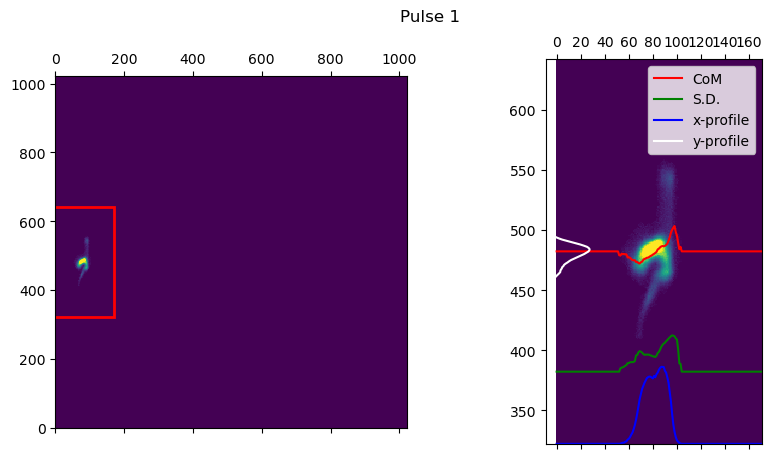

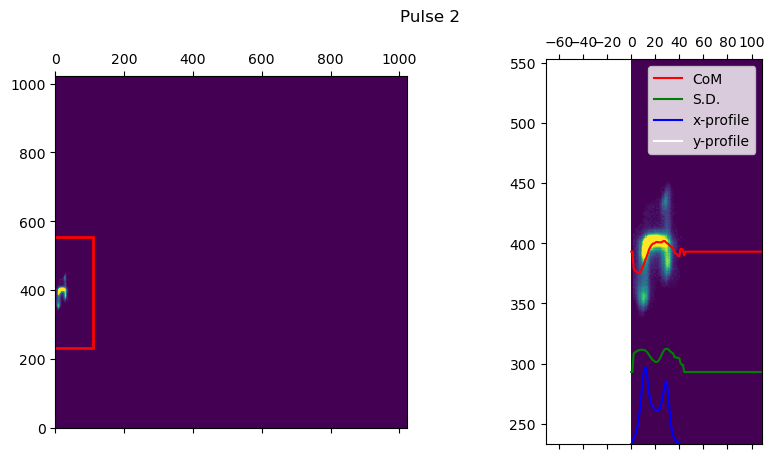

-------------------------------
Showing usable shot #1001:
-------------------------------


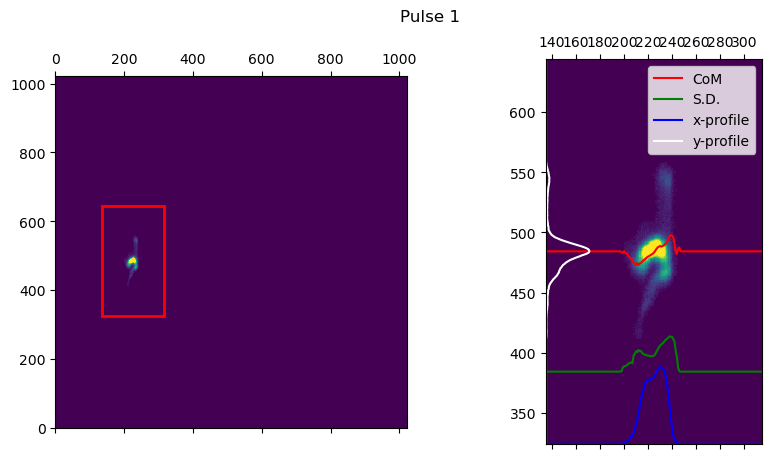

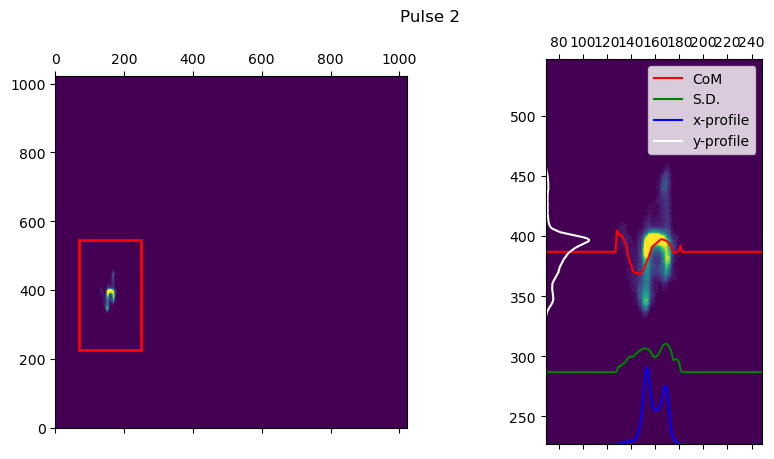

-------------------------------
Showing usable shot #2001:
-------------------------------


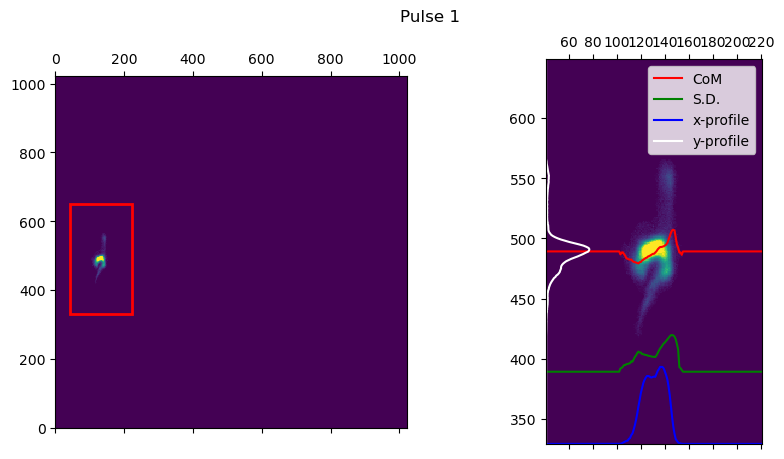

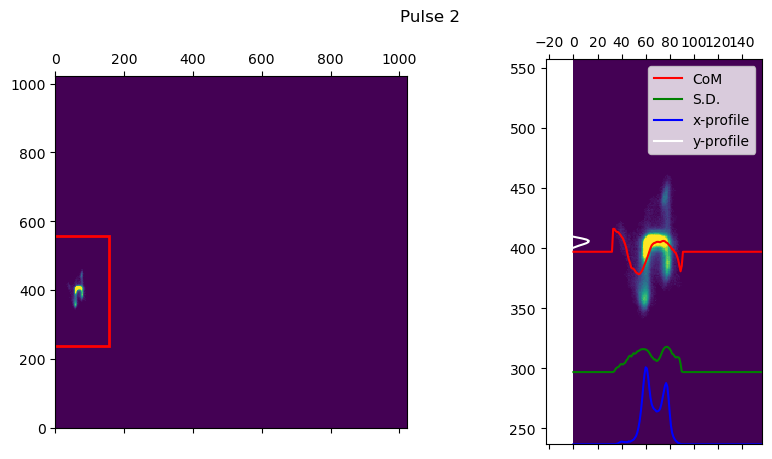

-------------------------------
Showing usable shot #3001:
-------------------------------


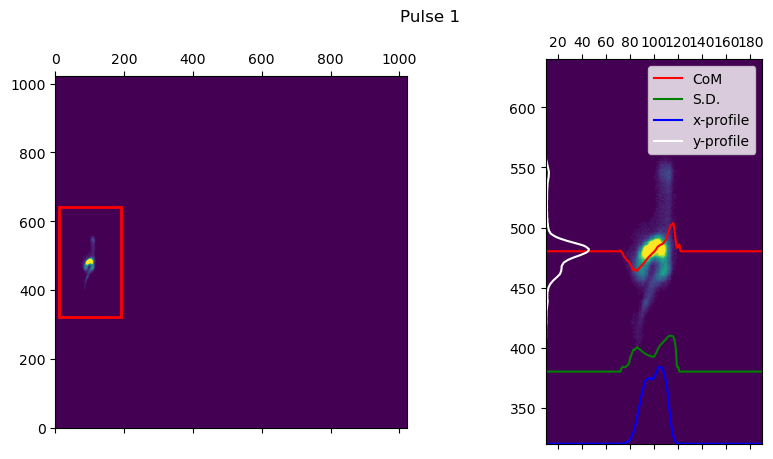

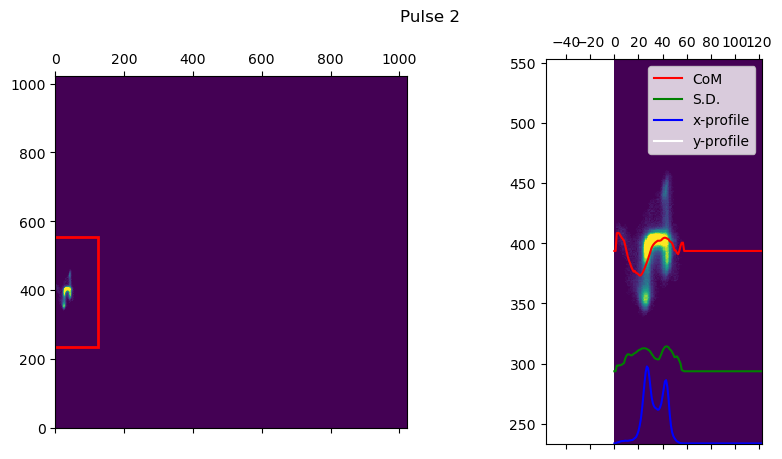

-------------------------------
Showing usable shot #4001:
-------------------------------


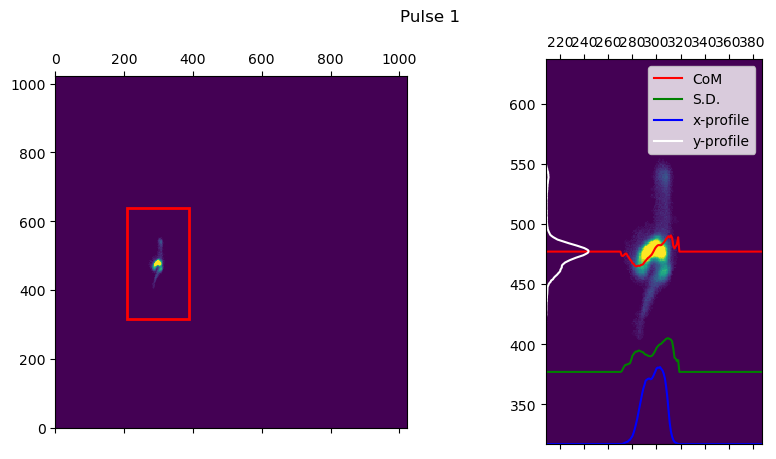

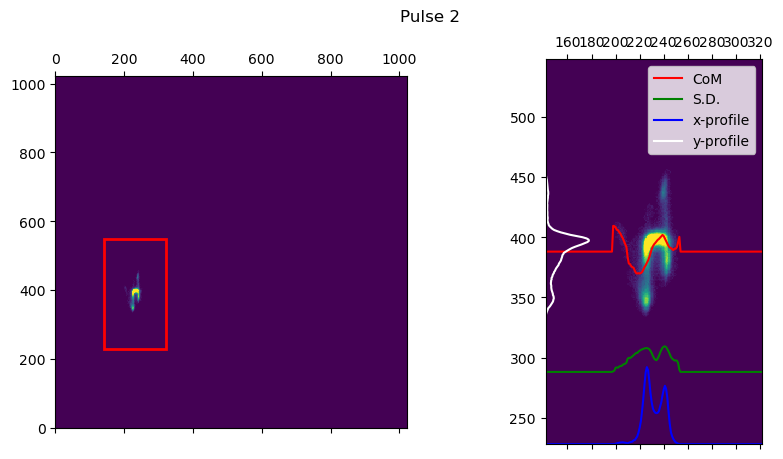

-------------------------------
Showing usable shot #5001:
-------------------------------


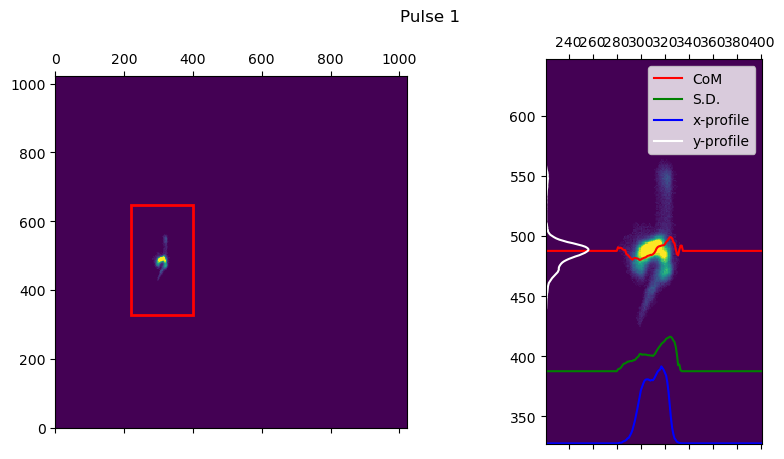

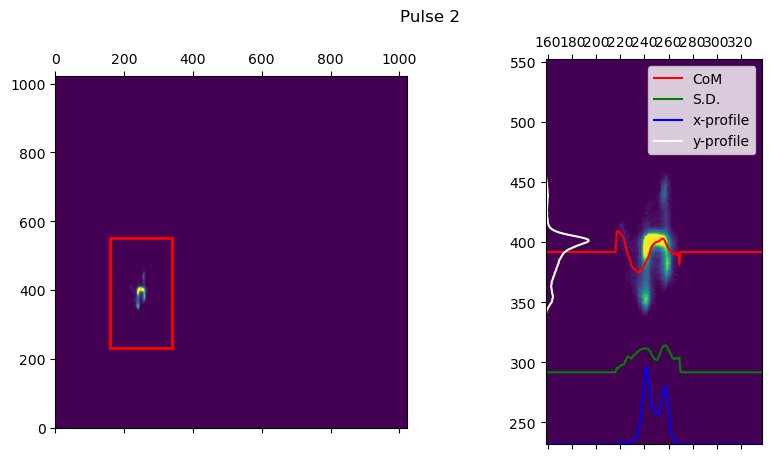

In [13]:
# Show a few shots & their pulse statistics

for i in [0,1000,2000,3000,4000,5000]:       # select a few shots
    print("-------------------------------")
    print(f"Showing usable shot #{i+1}:")
    print("-------------------------------")
    xtpr.show_pulse_statistics(
        i,
        n_pulses=2,
    )

## Get lasing-off average profiles

In [14]:
# Get lasing-off reference profiles

xtpr.calculate_reference_profiles()

Looping through the 2 pulses:   0%|          | 0/2 [00:00<?, ?it/s]

Interpolating XTCAV profiles:   0%|          | 0/5017 [00:00<?, ?it/s]

Forming 50 groups & calculating averages:   0%|          | 0/50 [00:00<?, ?it/s]

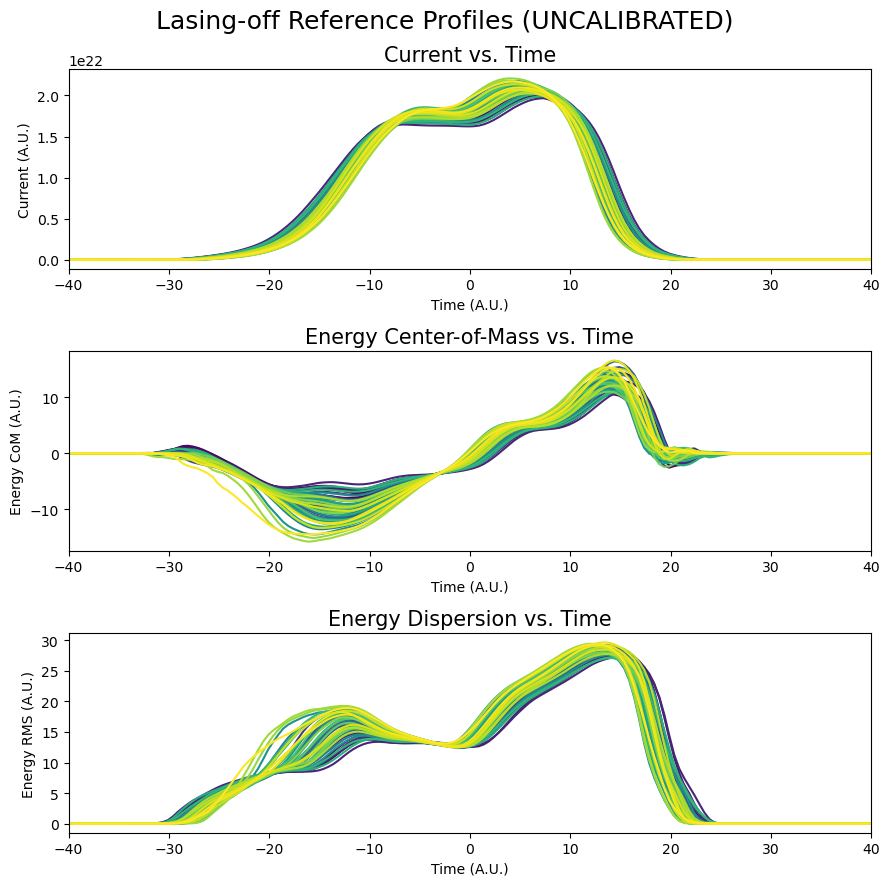

In [15]:
# Show reference profiles: 1'st pulse

xtpr.show_reference_profiles(
    idx_pulse=0,
    lims=[-40,40]
)

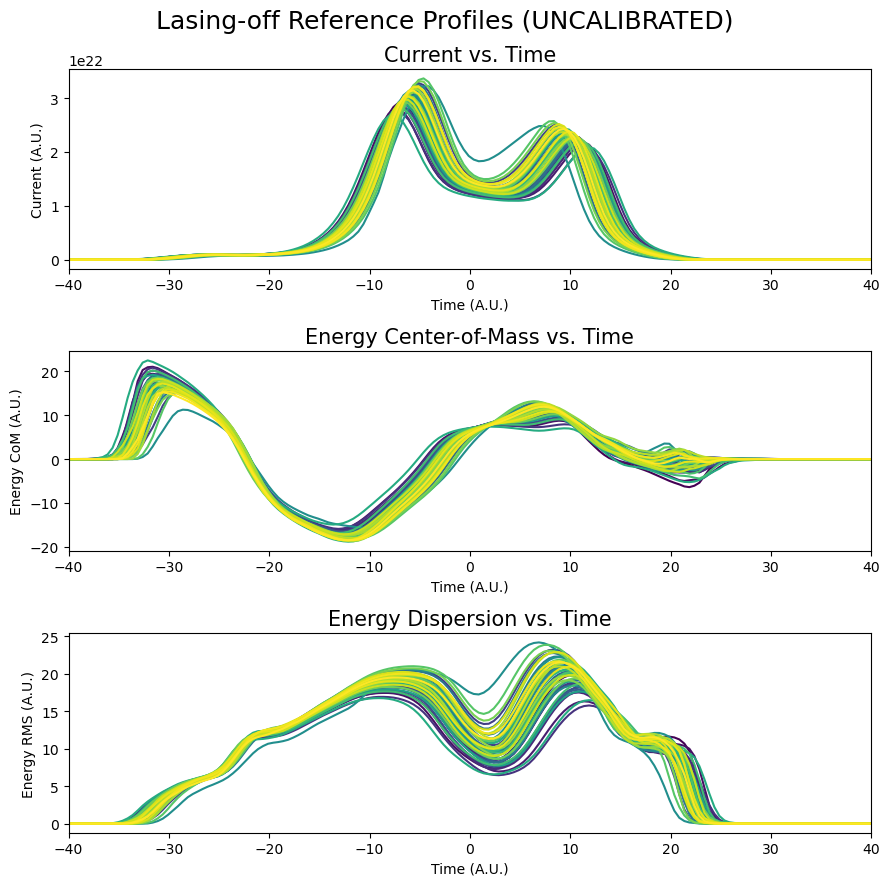

In [16]:
# Show reference profiles: 2'nd pulse

xtpr.show_reference_profiles(
    idx_pulse=1,
    lims=[-40,40]
)

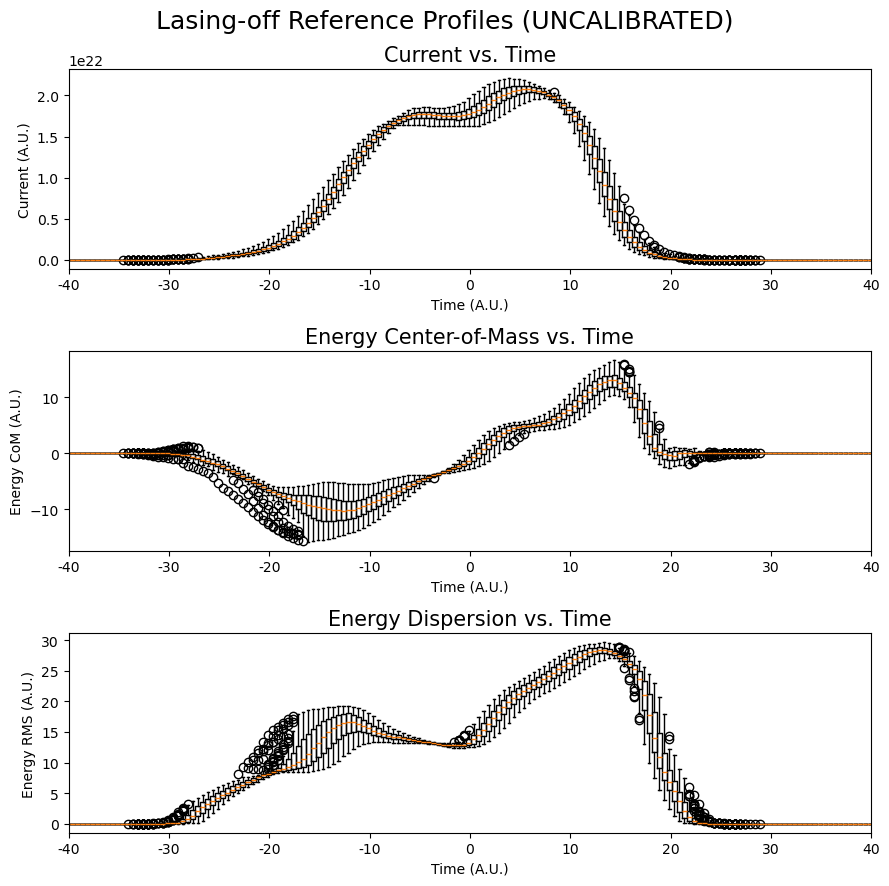

In [17]:
# Show reference profile boxplots: 1'st pulse

xtpr.show_reference_profiles_boxplots(
    idx_pulse=0,
    lims=[-40,40]
)

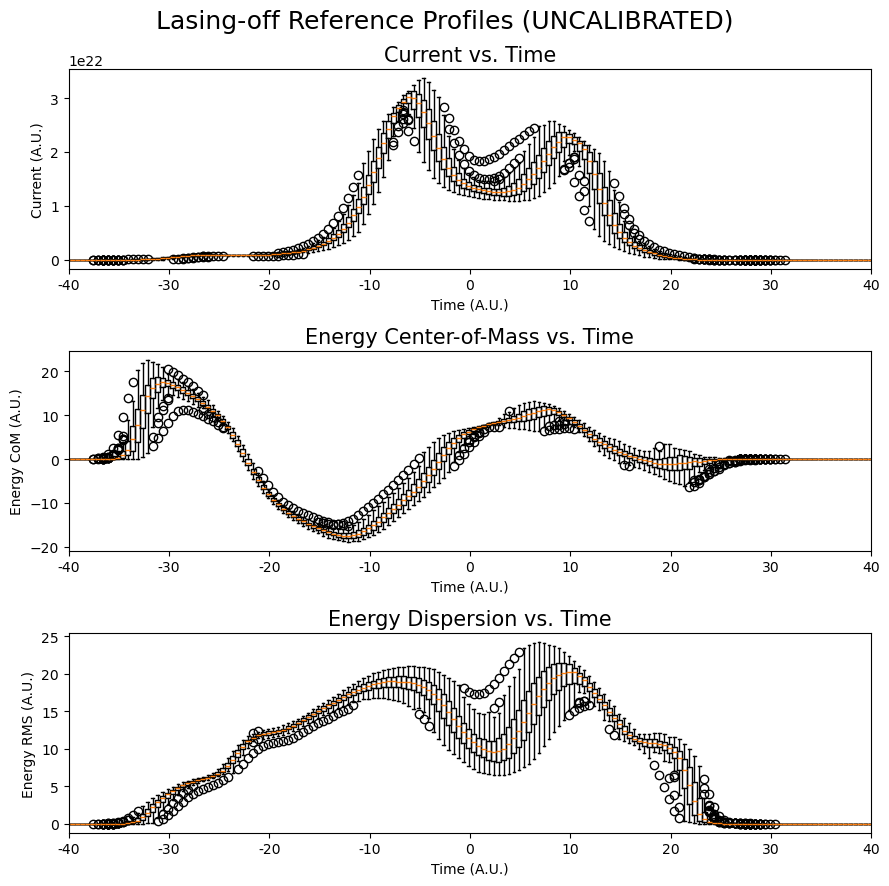

In [18]:
# Show reference profile boxplots: 2'nd pulse

xtpr.show_reference_profiles_boxplots(
    idx_pulse=1,
    lims=[-40,40]
)